In [1]:
%pip install numpy   

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

1. Create Column Names

In [3]:
columns = [
    "Sex",
    "Length",
    "Diameter",
    "Height",
    "Whole_weight",
    "Shucked_weight",
    "Viscera_weight",
    "Shell_weight",
    "Rings"
]

df = pd.read_csv("abalone.data", names=columns)

df.head()

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [4]:
#Convert Categorical Data into Number

In [5]:
df = pd.get_dummies(df, columns=["Sex"], drop_first=True)

df.head()

,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings,Sex_I,Sex_M
0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15,False,True
1,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7,False,True
2,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9,False,False
3,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10,False,True
4,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7,True,False


Create Input Features

In [6]:
X = df.drop("Rings", axis=1)
#Create Target Variable
y = df["Rings"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [9]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[11.76136132 10.24192648 14.00103561 11.99509311 11.16141477 10.23009202
  9.417632    9.14955846  7.1918906  10.80525772]


In [10]:
print("MAE :", mean_absolute_error(y_test, y_pred))

print("R2 Score :", r2_score(y_test, y_pred))

MAE : 1.5931067816608362
R2 Score : 0.5481628137889263


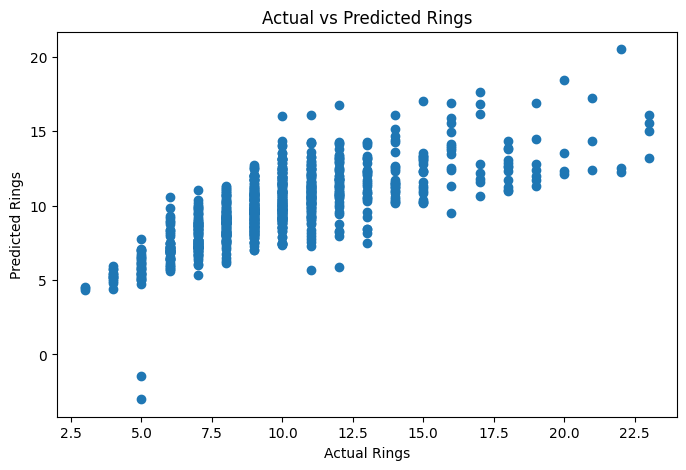

In [11]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Rings")
plt.ylabel("Predicted Rings")
plt.title("Actual vs Predicted Rings")

plt.show()

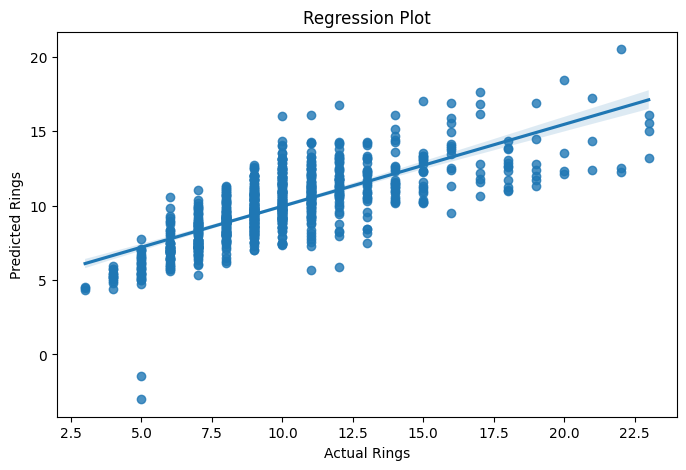

In [12]:
plt.figure(figsize=(8,5))

sns.regplot(x=y_test, y=y_pred)

plt.xlabel("Actual Rings")
plt.ylabel("Predicted Rings")
plt.title("Regression Plot")

plt.show()

   Rings   Age
0     15  16.5
1      7   8.5
2      9  10.5
3     10  11.5
4      7   8.5
MAE : 1.5931067816608362
R2 Score : 0.5481628137889263


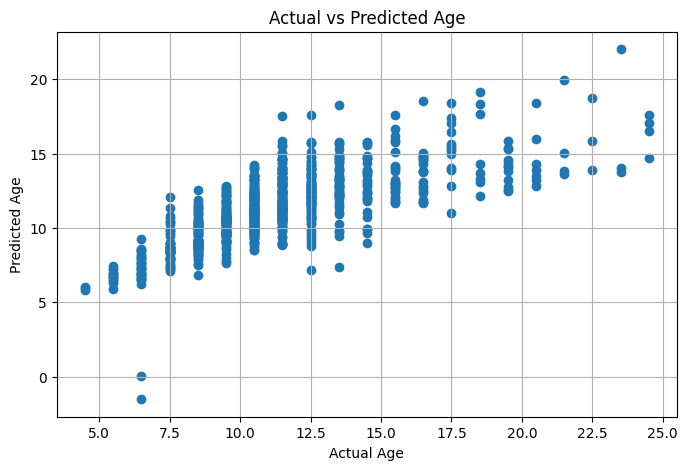

In [13]:
df["Age"] = df["Rings"] + 1.5

# Display Age Column
print(
    df[["Rings", "Age"]].head()
)

X = df.drop(
    ["Rings", "Age"],
    axis=1
)

y = df["Age"]

# ----------------------------------------
# Train-Test Split
# ----------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


model = LinearRegression()

model.fit(X_train, y_train)



y_pred = model.predict(X_test)


print(
    "MAE :",
    mean_absolute_error(
        y_test,
        y_pred
    )
)

print(
    "R2 Score :",
    r2_score(
        y_test,
        y_pred
    )
)

# ----------------------------------------
# Actual vs Predicted Age Plot
# ----------------------------------------

plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual Age")

plt.ylabel("Predicted Age")

plt.title(
    "Actual vs Predicted Age"
)

plt.grid()

plt.show()

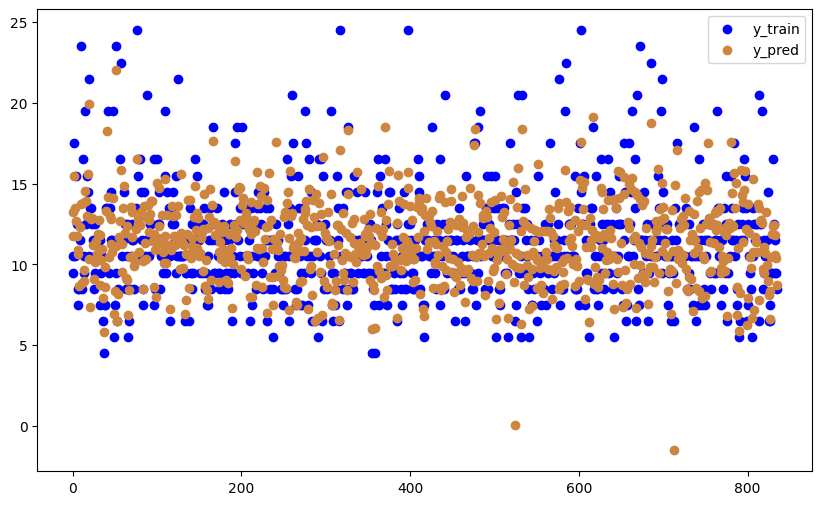

In [39]:
fig = plt.figure(figsize=(10, 6))
plt.scatter(range(y_test.shape[0]), y_test, color="blue", label="y_train")
plt.scatter(range(y_test.shape[0]), y_pred, color="peru", label="y_pred")
plt.legend();




*






CLASSIFICATION WAY




*



In [16]:
def classify_rings(rings):

    if rings <= 8:
        return 'Young'

    elif rings <= 15:
        return 'Adult'

    else:
        return 'Old'


df['Ring_Class'] = df['Rings'].apply(classify_rings)

print(df[['Rings', 'Ring_Class']].head())

   Rings Ring_Class
0     15      Adult
1      7      Young
2      9      Adult
3     10      Adult
4      7      Young


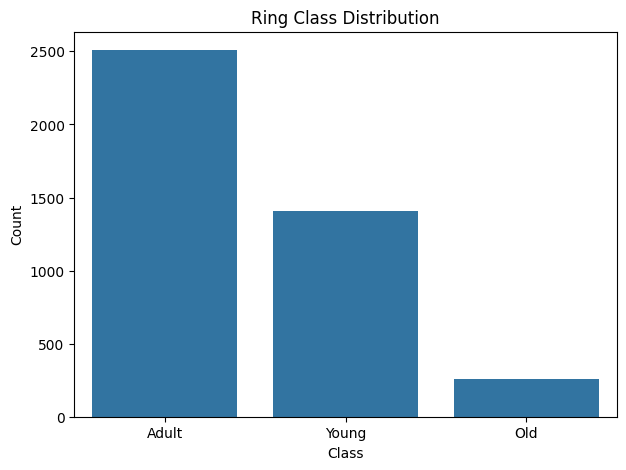

In [17]:
plt.figure(figsize=(7,5))

sns.countplot(x=df['Ring_Class'])

plt.title("Ring Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

In [18]:
X = df.drop(['Rings', 'Ring_Class'], axis=1)

y = df['Ring_Class']

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
from sklearn.tree import DecisionTreeClassifier

classifier = DecisionTreeClassifier(random_state=42)

classifier.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [21]:
y_pred_class = classifier.predict(X_test)

print(y_pred_class[:10])

['Adult' 'Young' 'Old' 'Adult' 'Adult' 'Adult' 'Young' 'Young' 'Young'
 'Adult']


In [22]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred_class)

print("Accuracy:", accuracy)

Accuracy: 1.0


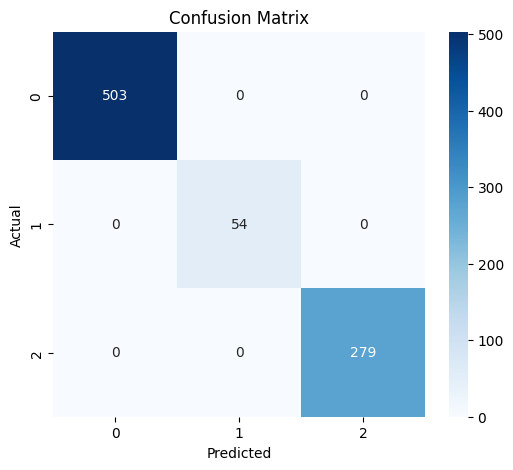

In [23]:
cm = confusion_matrix(y_test, y_pred_class)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [24]:
print(classification_report(y_test, y_pred_class))

              precision    recall  f1-score   support

       Adult       1.00      1.00      1.00       503
         Old       1.00      1.00      1.00        54
       Young       1.00      1.00      1.00       279

    accuracy                           1.00       836
   macro avg       1.00      1.00      1.00       836
weighted avg       1.00      1.00      1.00       836



B PART

In [25]:
df['Age'] = df['Rings'] + 1.5

print(df[['Rings', 'Age']].head())

   Rings   Age
0     15  16.5
1      7   8.5
2      9  10.5
3     10  11.5
4      7   8.5


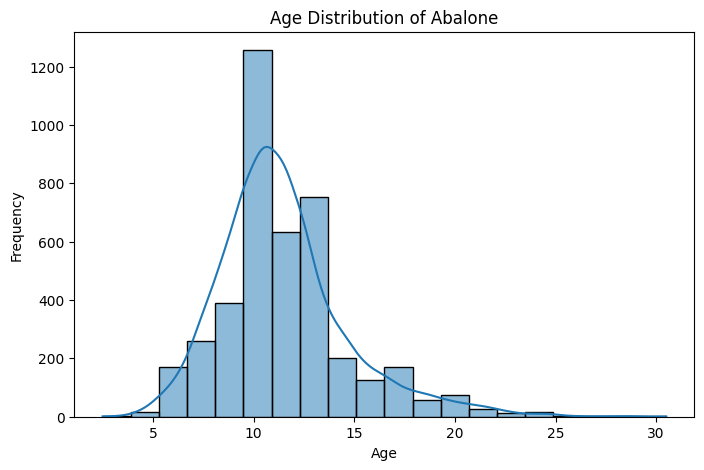

In [26]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=20, kde=True)

plt.title("Age Distribution of Abalone")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

In [27]:
# Features
X = df.drop(['Rings', 'Ring_Class', 'Age'], axis=1, errors='ignore')

# Target variable

y = df['Age']

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [29]:
age_model = LinearRegression()

age_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [30]:
age_pred = age_model.predict(X_test)

print("Predicted Ages: ")
print(age_pred[:10])

Predicted Ages: 
[13.26136132 11.74192648 15.50103561 13.49509311 12.66141477 11.73009202
 10.917632   10.64955846  8.6918906  12.30525772]


In [31]:
age_mae = mean_absolute_error(y_test, age_pred)
age_mse = mean_squared_error(y_test, age_pred)
age_r2 = r2_score(y_test, age_pred)

print("Mean Absolute Error:", age_mae)
print("Mean Squared Error:", age_mse)
print("R2 Score:", age_r2)

Mean Absolute Error: 1.5931067816608362
Mean Squared Error: 4.891232447128579
R2 Score: 0.5481628137889263


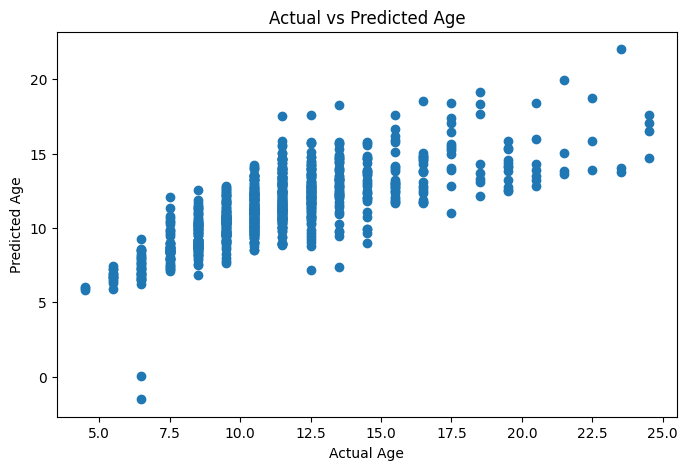

In [32]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, age_pred)

plt.xlabel("Actual Age")
plt.ylabel("Predicted Age")
plt.title("Actual vs Predicted Age")

plt.show()

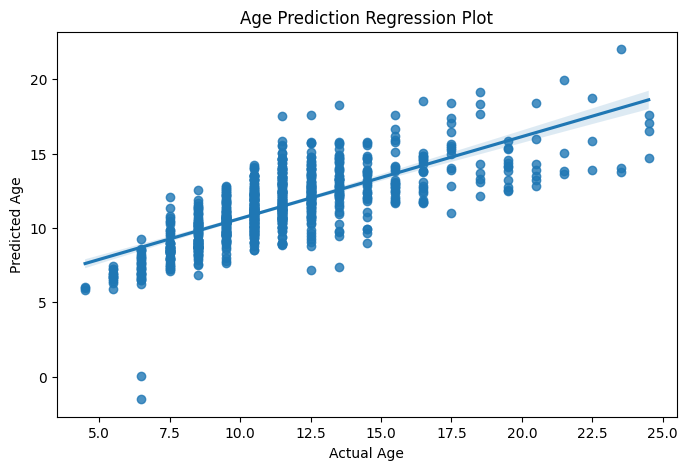

In [33]:
plt.figure(figsize=(8,5))

sns.regplot(x=y_test, y=age_pred)

plt.xlabel("Actual Age")
plt.ylabel("Predicted Age")
plt.title("Age Prediction Regression Plot")

plt.show()

In [34]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': age_model.coef_
})

coefficients.style \
    .background_gradient(cmap='plasma') \
    .set_caption("Feature Importance using Linear Regression")

,Feature,Coefficient
0,Length,-0.201554
1,Diameter,11.123391
2,Height,10.445325
3,Whole_weight,8.932176
4,Shucked_weight,-20.256545
5,Viscera_weight,-9.558916
6,Shell_weight,8.792378
7,Sex_I,-0.718974
8,Sex_M,0.103276


Complete Algorithm
Algorithm — Part (a)
Predict Rings using Regression
1. Start
2. Import required libraries
3. Load Abalone dataset
4. Assign column names
5. Check dataset information
6. Encode categorical feature (Sex)
7. Define input features and target variable (Rings)
8. Split dataset into training and testing sets
9. Apply Linear Regression model
10. Train model using training data
11. Predict rings using testing data
12. Evaluate model using MAE and R² score
13. Display graphs and results
14. Stop
Algorithm — Part (b)
Predict Age using Linear Regression
1. Start
2. Create Age column using:
   Age = Rings + 1.5
3. Define input features and target variable (Age)
4. Split dataset into training and testing sets
5. Apply Linear Regression
6. Train the model
7. Predict age values
8. Evaluate model performance
9. Visualize prediction results
10. Stop